<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%BE%A9%E7%BF%92%E7%94%A8%E6%95%99%E6%9D%90/%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E5%9F%BA%E7%A4%8E%E2%91%A2%E6%95%99%E5%B8%AB%E3%81%AA%E3%81%97%E5%AD%A6%E7%BF%92_%E8%AC%9B%E5%B8%AB%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

必要なデータを予め準備しておきます。

In [ ]:
#データ分析ライブラリ
import numpy as np
import numpy.random as random
import scipy as sp
import pandas as pd
from pandas import Series,DataFrame

#可視化ライブラリ
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

#機械学習ライブラリ
from sklearn.cluster import KMeans

#データセットの準備
from sklearn.datasets import make_blobs

#小数第3位まで表示
%precision 2

#データフレームが全列表示されるように設定
pd.set_option('display.max_columns', None)

'%.2f'

# <font color=#0e89b2>1. 教師あり学習とは</font>

## <font color=#0e89b2>1.1 教師あり学習と教師なし学習</font>

くどいくらい復習になってきましたが、再度おさらいしておきます。

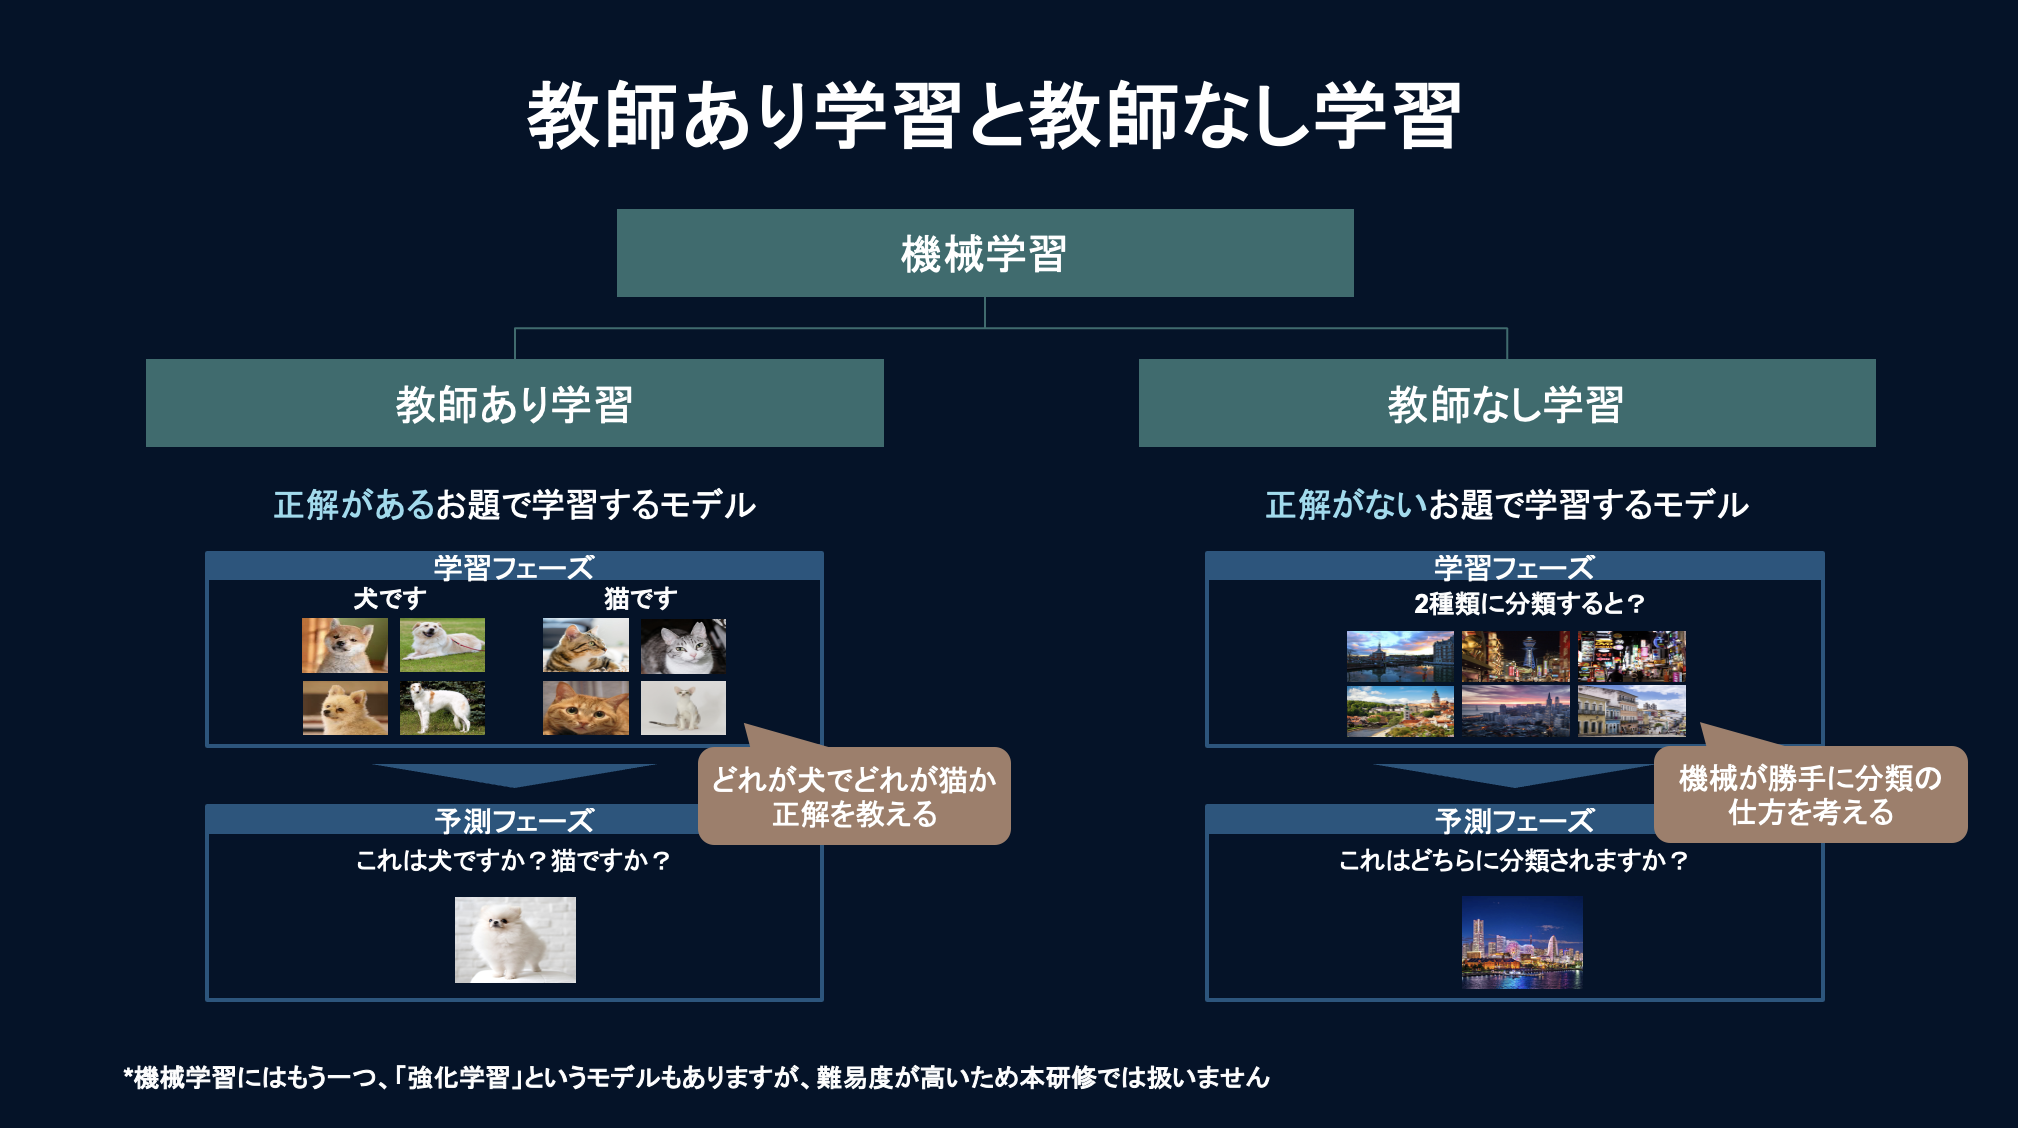



---


*   <font color=#f27405>教師あり学習</font>：
 * 正解があるお題で学習するモデル
 * 使用例：家賃予測（家賃という正解数値を与える）、犬と猫の画像判別（犬/猫という正解ラベルを与える）
*   <font color=#f27405>教師なし学習</font>：
 * 正解がないお題で学習するモデル
 * モデルが自分でパターンや傾向を見出す
 * 使用例：顧客属性のクラスタリング、犬と猫の画像判別（犬/猫という正解ラベルを与えない）


---



ここでの注意点としては、例えば同じ「犬猫画像判別モデル」であっても、<br>
学習データとして「この画像は犬」「この画像は猫」と正解ラベルを与えていたら「教師あり学習」になるし、<br>
逆に、犬猫の正解ラベルをつけることなく、ただ画像だけをどさっと与えたら「教師なし学習」になるということです。<br>
<br>
このあたりは抽象的に説明されてもあまりピンとこないとは思いますが、<br>
今後色々な実例を見たり実装したりすることで、どんどん解像度が高まっていくはずです。

## <font color=#0e89b2>1.2 クラスタリングと次元削減</font>

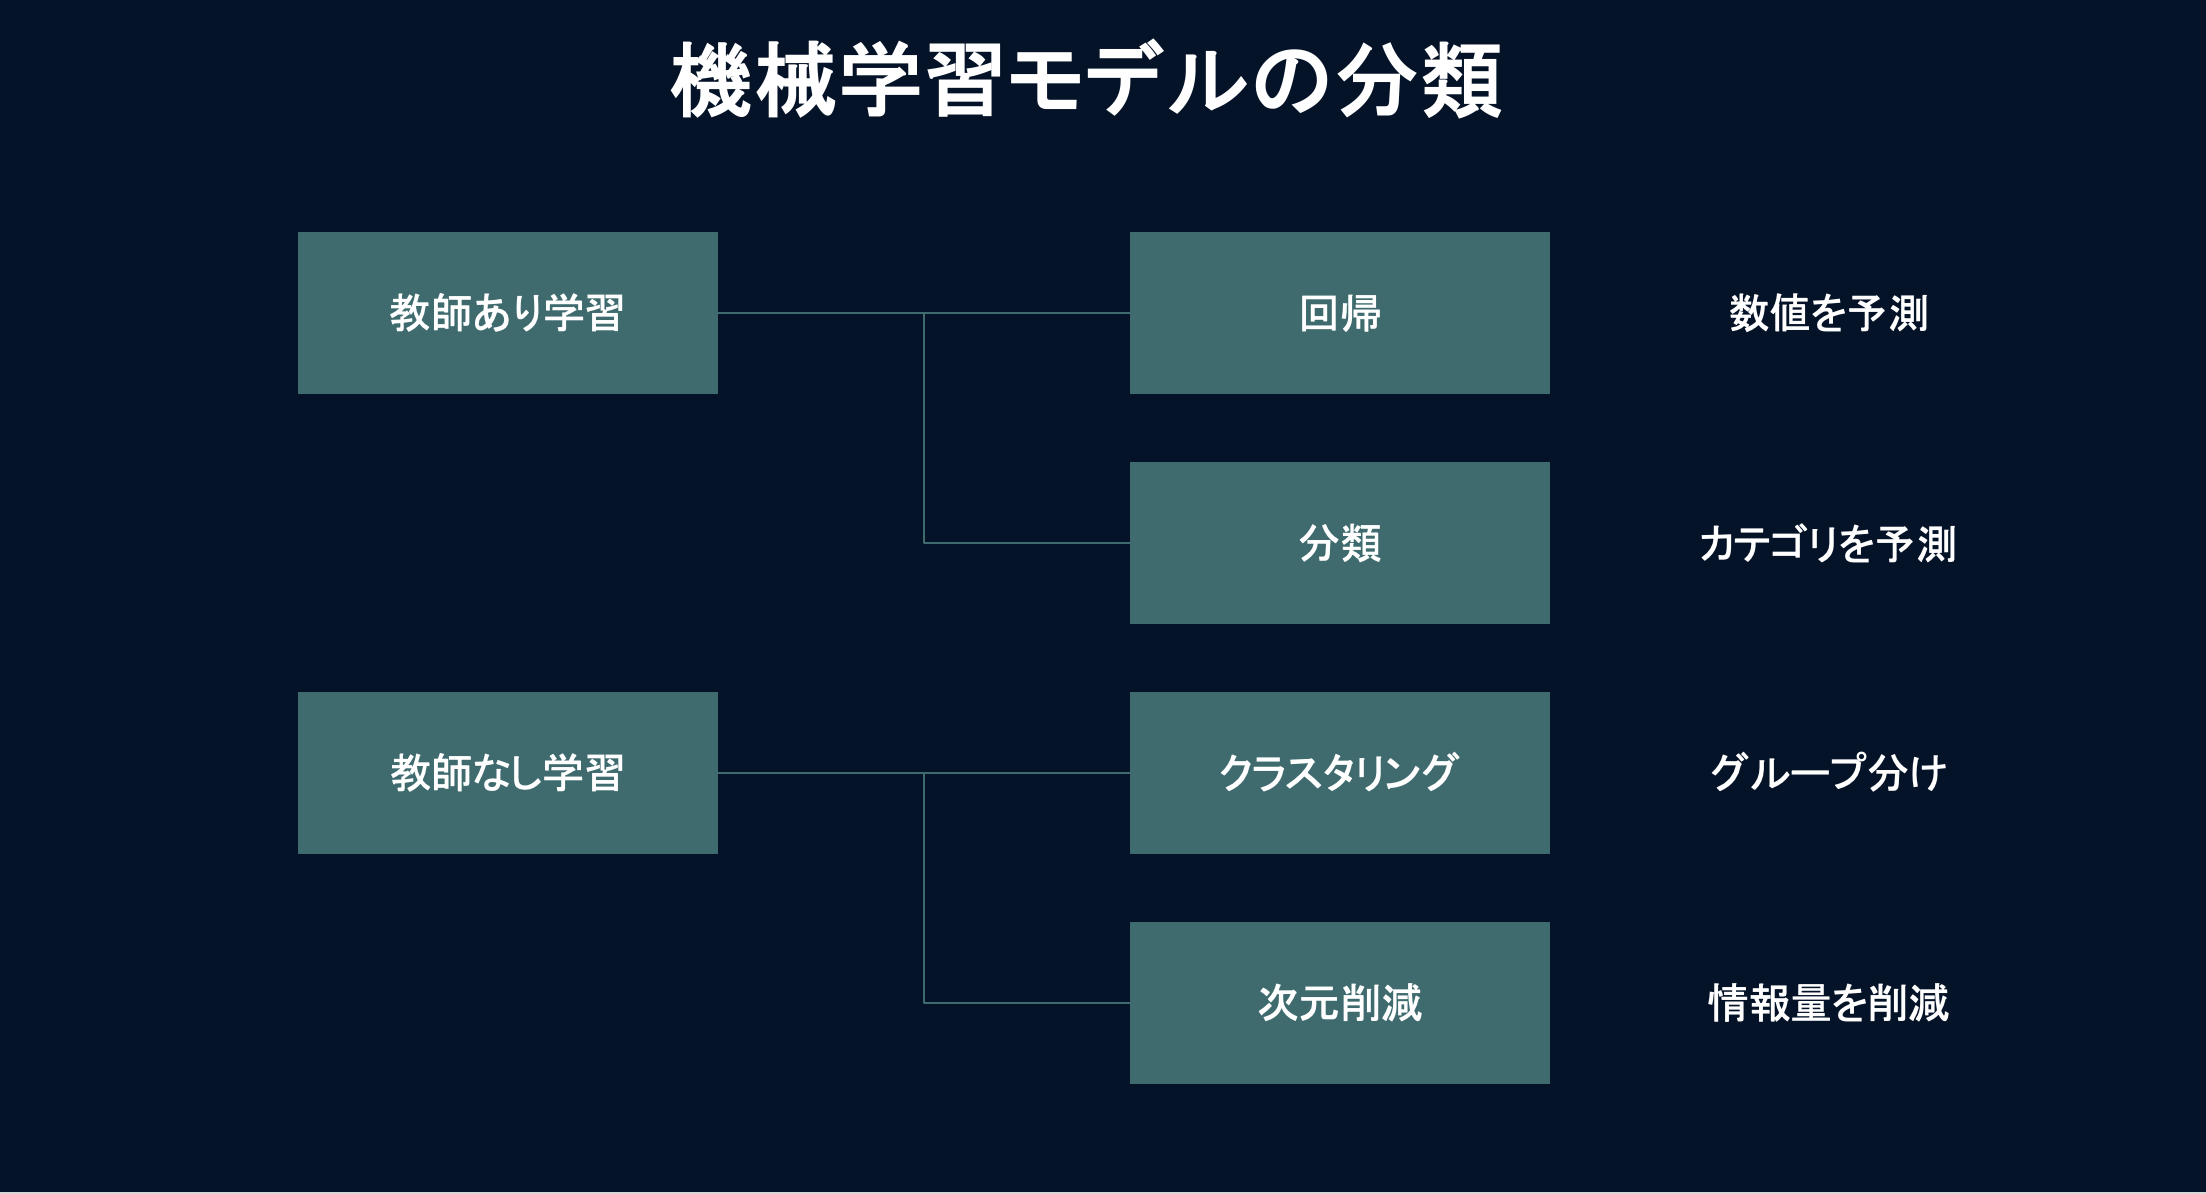

教師なし学習は、主に<font color=#f27405>クラスタリング</font>と<font color=#f27405>次元削減</font>に分類されます。<br>

---



*   <font color=#f27405>クラスタリング</font>：データを特定のルールに基づいていくつかのグループ（クラスタ）に分類すること
 * 例)顧客データから、顧客をロイヤルカスタマーとそれ以外に分類する
*   <font color=#f27405>次元削減</font>：多数の変数があるときに、それを少数の項目（2～3程度）に置き換えることで、データを解釈しやすくすること




---

ただし実務の場面では、次元削減が行われる機会はああり多くないので、本研修ではクラスタリングのみを勉強します。

## <font color=#0e89b2>1.3 主なアルゴリズム</font>

教師あり学習とは異なり、教師なし学習で一般的に使われるアルゴリズムの種類は限られています。<br>
<br>
* クラスタリングの主なアルゴリズム：<font color=#f27405>k-Means</font>
* 次元削減の主なアルゴリズム：<font color=#f27405>主成分分析（PCA）</font>

# <font color=#0e89b2>2. クラスタリングモデルの実装</font>

## <font color=#0e89b2>2.1 クラスタリングとは</font>

クラスタリングの例を挙げておきます。

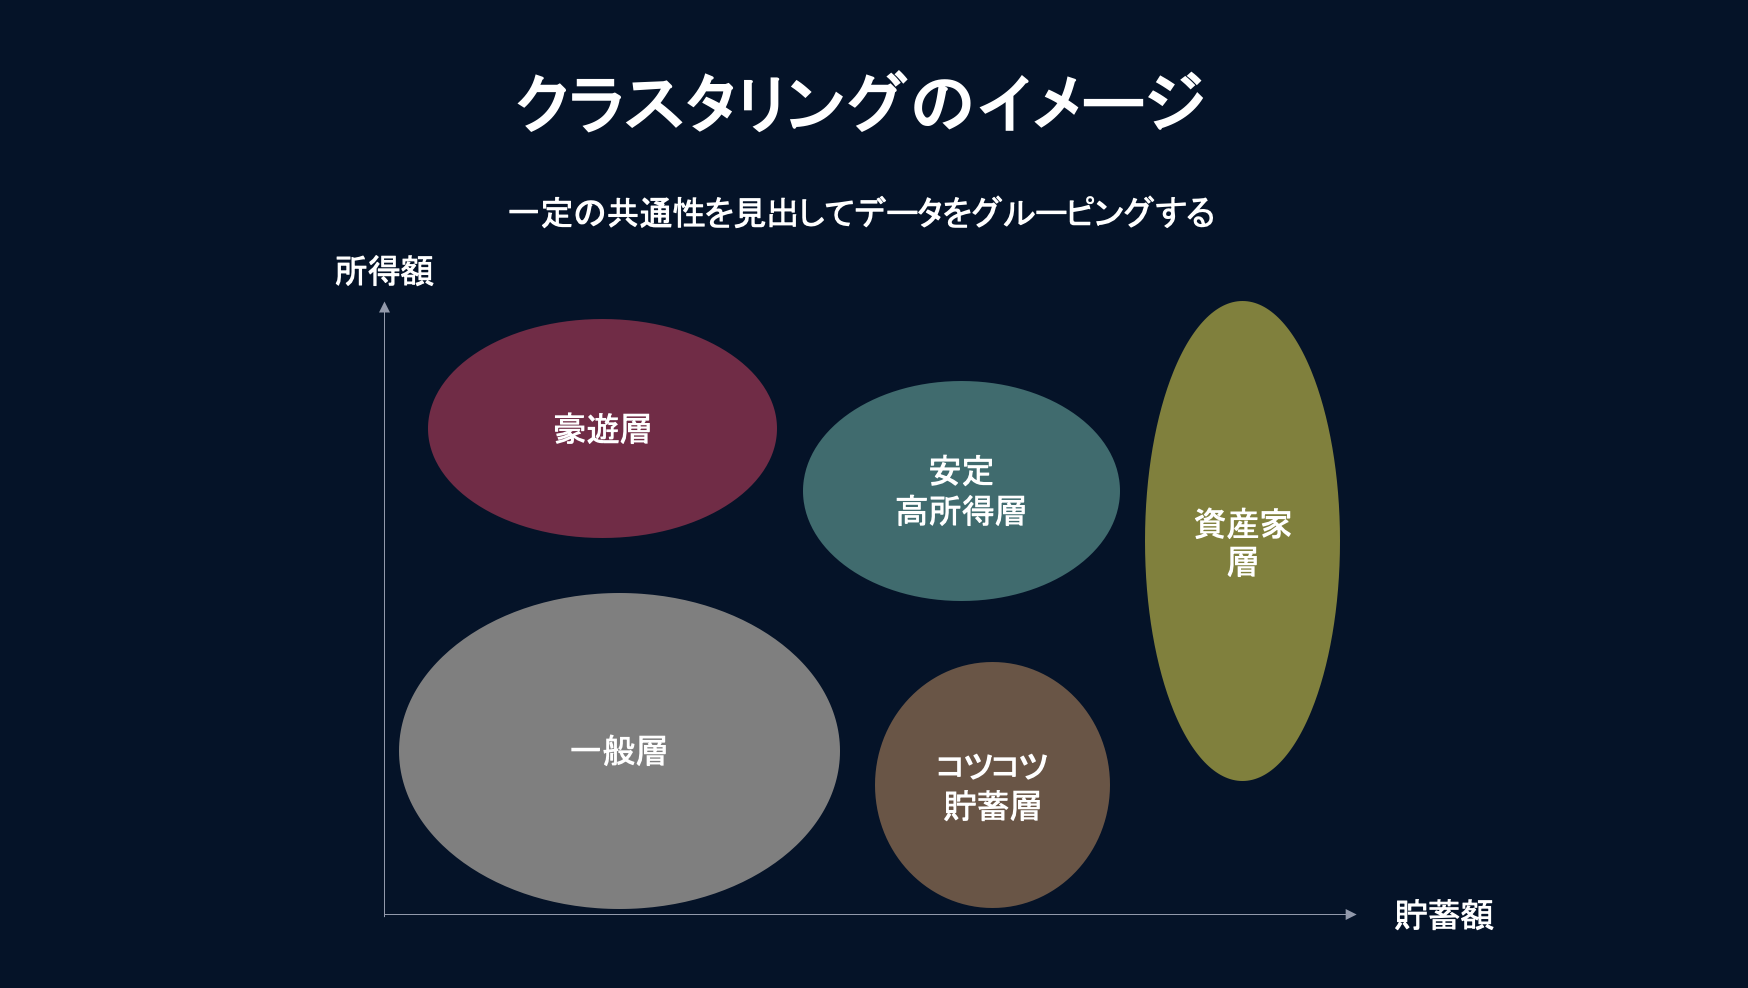

このように、無秩序に散らばったデータに対しても、一定の括りでグルーピングして、<br>
ざっくり「このグループは○◯だ」と名付けをすると、ビジネスの現場においては議論が進みやすいです。<br>
<br>
例えば、ロボアド投資サービスを新規事業として立ち上げる際に、メインターゲットを検討する場合、<br>
上のグルーピングに基づいて、<br>
「資産家層は大手証券会社に抑えられているからターゲット外としよう」<br>
「証券会社の唾はついていないが比較的所得も貯蓄額も多い『安定高所得層』はターゲットとして魅力的」<br>
などの議論をすることができます。<br>
<br>
ここで機械学習に話を戻します。<br>
上のような二次元のデータでは、機械学習を使うよりも人間が目視と頭で考えてグルーピングして、名付けを行った方が早いと思います。<br>
しかし人間の脳では、三次元のデータを眺めて意味を考えながらグルーピングを行うのは、相当厳しいです。<br>
<br>
なので、機械学習によるクラスタリングが主に威力を発揮するのは、データが三次元以上の場合でしょう。<br>

## <font color=#0e89b2>2.2 k-Meansの仕組み</font>

k-Meansの仕組みは図の通りで、結構面白いアルゴリズムです。<br>

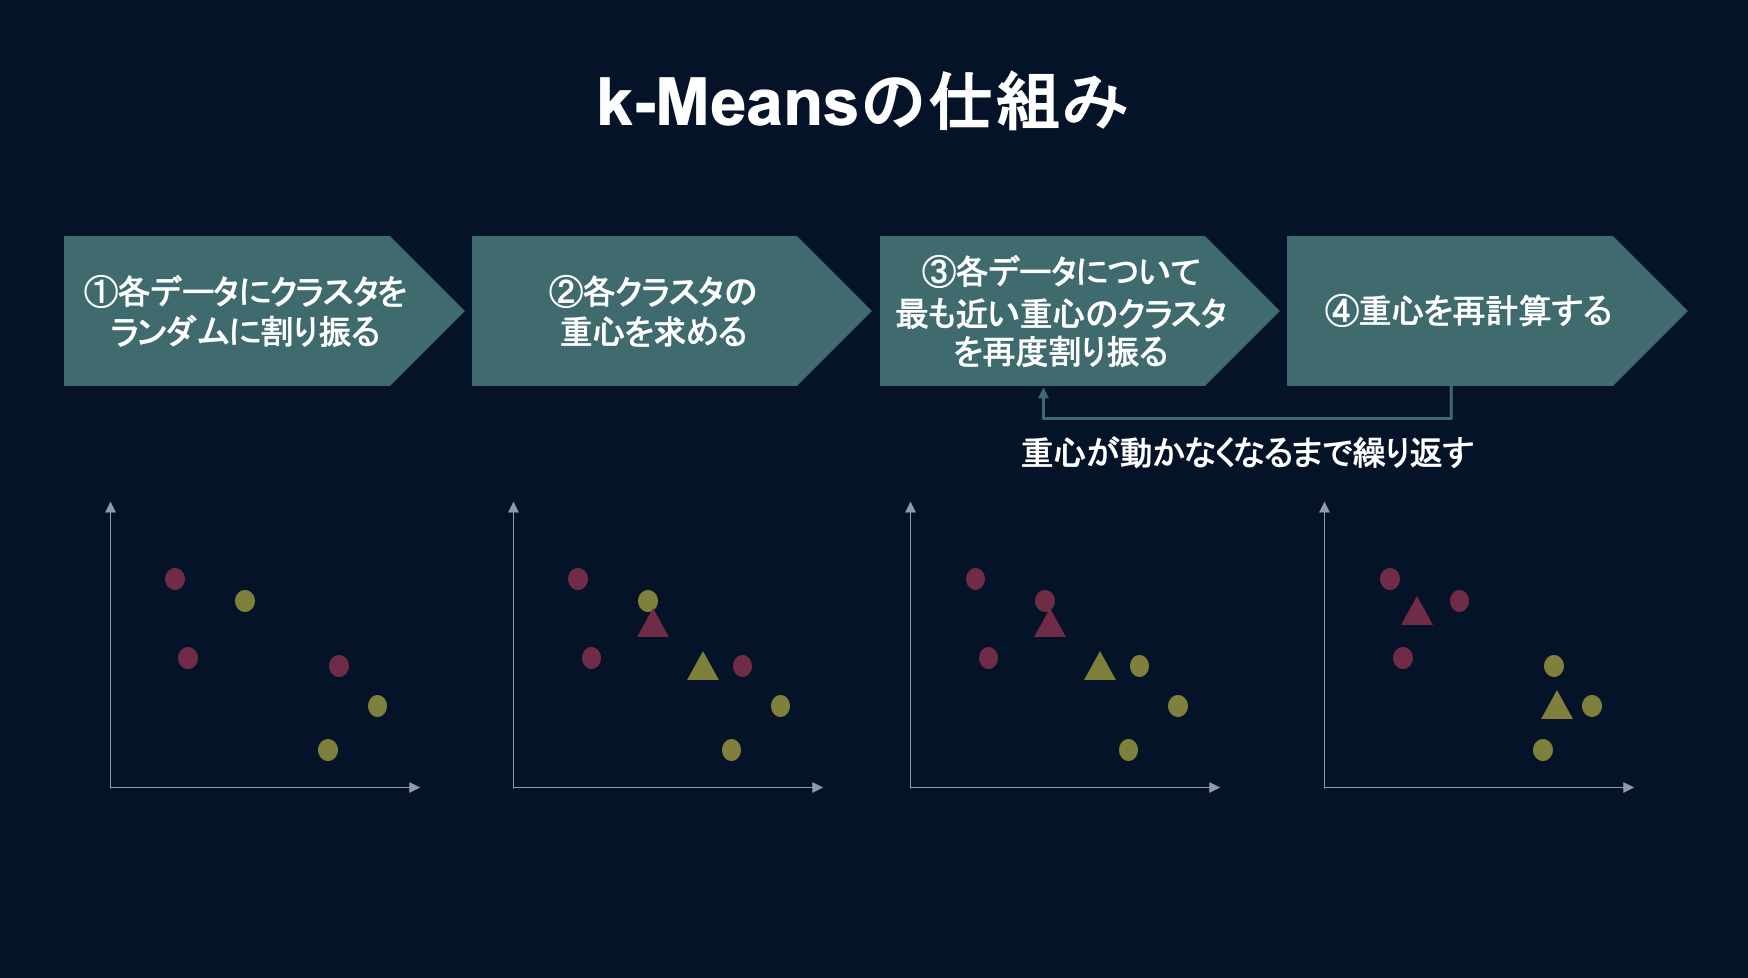

## <font color=#0e89b2>2.3 k-Meansの実装</font>

サンプルデータを準備します。

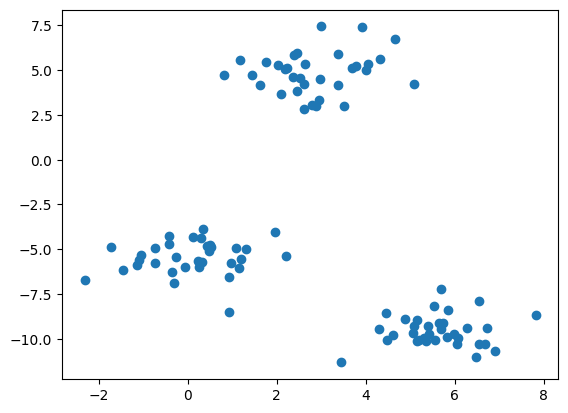

In [ ]:
#サンプルデータの作成
#make_blobsは2つの値を返すため、一方は使用しない「_」で受け取る
sample_data,_ = make_blobs(random_state=10)
data = pd.DataFrame(sample_data)
x = data[[0]]
y = data[[1]]

#グラフを描画
plt.scatter(x, y)

このデータに対してクラスタリングを行っていきます。<br>
人間の目で見れば3グループに分かれるのが自明ですが、一応機械学習モデルにやらせてみましょう。<br>
例によって、モデルの構築は一瞬で終わります。（scikit-learnさまさま）

In [ ]:
#####写経#####
#モデルの作成
model = KMeans(n_clusters=3)

#学習
model.fit(data)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=3)

ここで注意です！<br>
ここからどうしていくでしょうか？<br>
<br>
教師あり学習のときは、この後「予測→評価」と進んでいきました（例の「機械学習の4ステップですね）が、<br>
教師なし学習のときは<font color=#f27405>「評価もくそもない」</font>ことが分かるでしょうか？

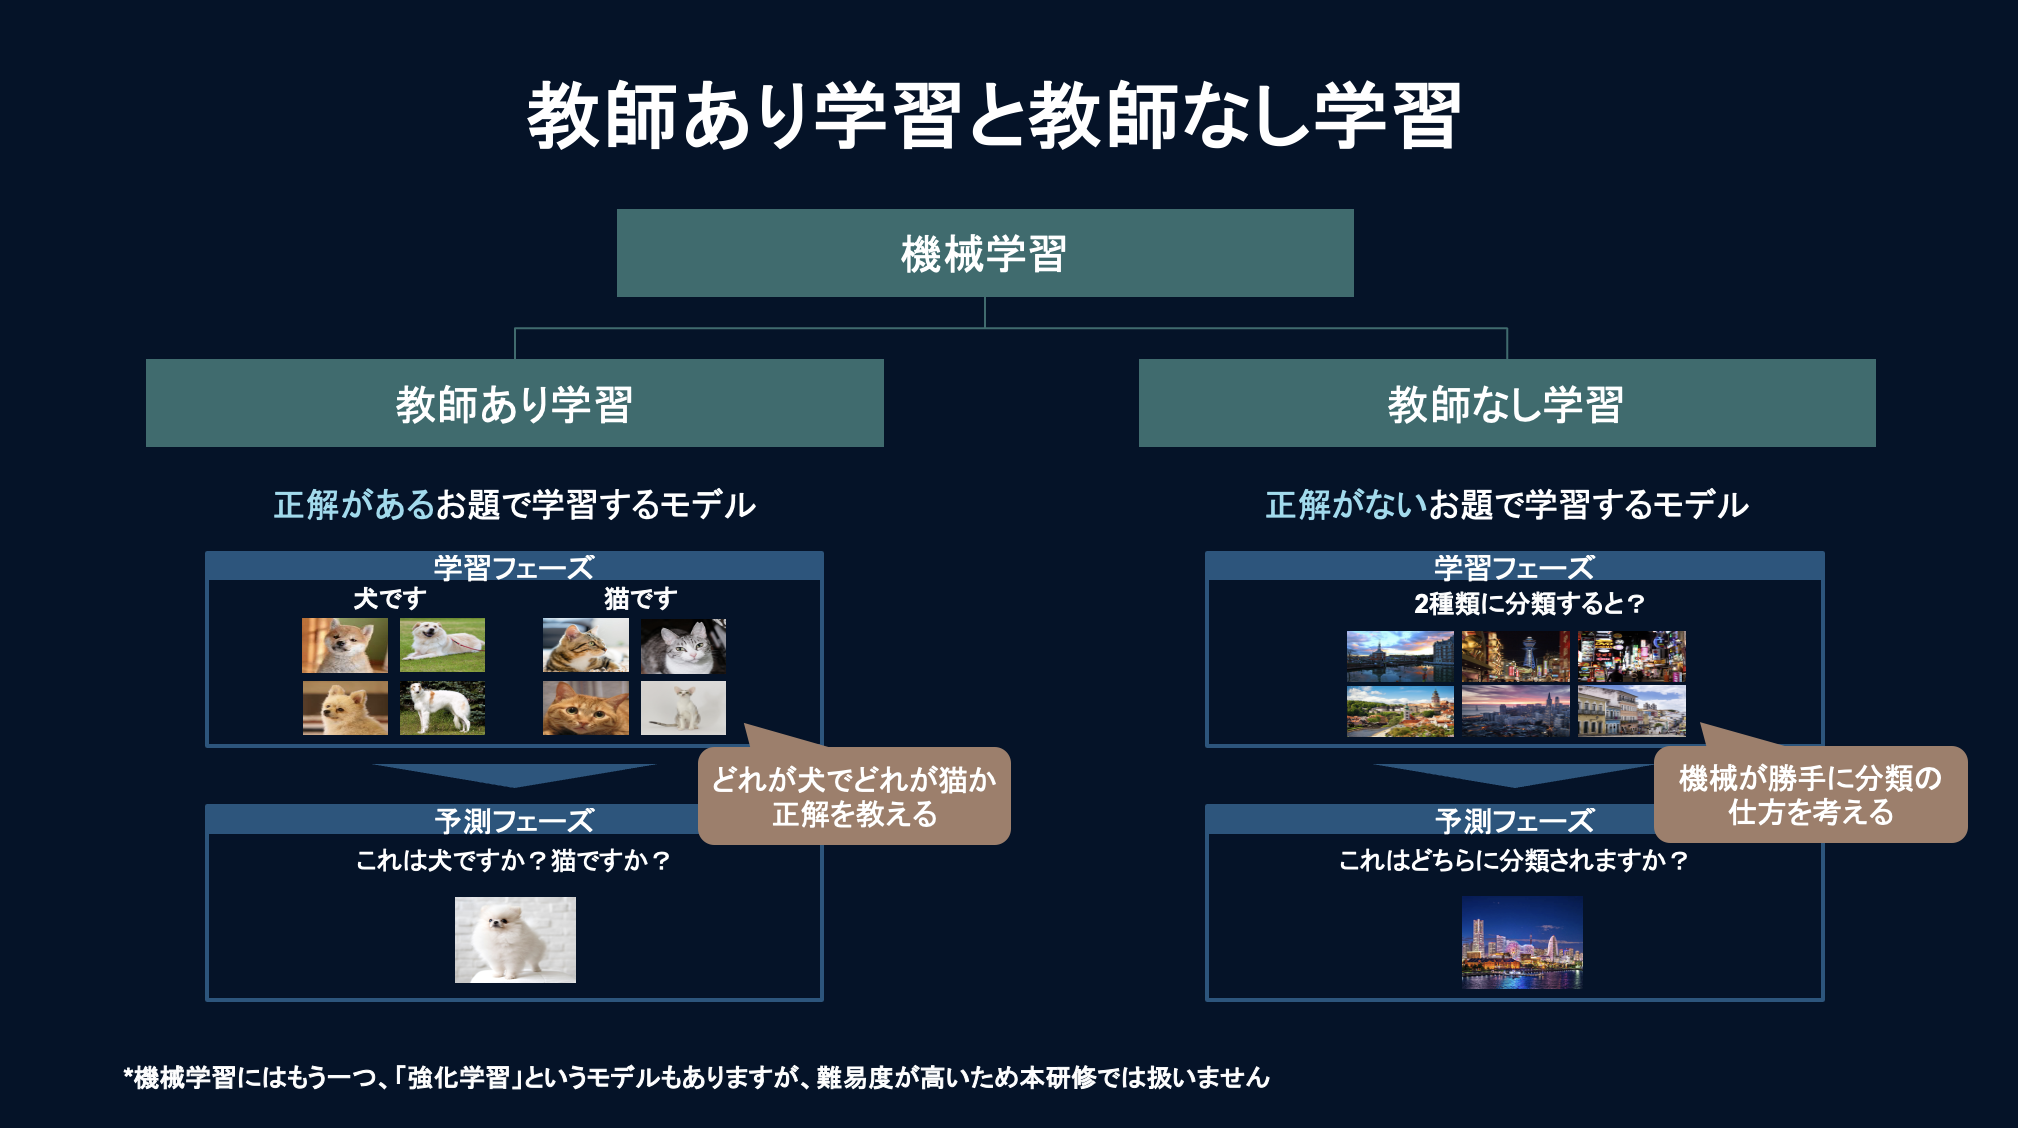

教師なし学習は、そもそも<font color=#f27405>正解のないお題に取り組んでいる</font>わけなので、<br>
正解率みたいな評価指標がそもそも定義できないんですね。<br>
<br>
なので、モデルがどのデータをどのクラスタに分類したかの予測値を出力するところまででおしまいです。<br>
<br>
予測値は、このように表示できます。

In [ ]:
#####写経#####
#予測（各データがどのクラスターに分類されているか）
y_pred = model.predict(data)
y_pred

array([2, 2, 1, 0, 1, 1, 0, 2, 1, 0, 0, 1, 1, 2, 2, 1, 0, 1, 0, 1, 0, 2,
       1, 2, 0, 1, 1, 1, 1, 0, 2, 1, 1, 0, 2, 2, 2, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 0, 0, 2, 0, 1, 2, 0, 0, 2, 0, 1, 2, 0, 0, 1, 1, 2, 2, 2, 0,
       0, 2, 2, 2, 1, 0, 1, 1, 2, 1, 1, 2, 0, 0, 0, 1, 0, 1, 2, 1, 2, 0,
       2, 2, 0, 0, 0, 2, 2, 2, 1, 0, 0, 0], dtype=int32)

## <font color=#0e89b2>練習問題1：クラスタリング結果の描画</font>

上のk-Meansモデルの予測結果を、グラフに描画してください。<br>
具体的には、
クラスター0と判定した点を"blue"、クラスター1を"green"、クラスター2を"red"でプロットしましょう。

In [ ]:
#クラスタリング結果を描画


解答

In [ ]:
#描画用にデータをデータフレーム形式で整理
data = pd.concat([pd.DataFrame(x), pd.DataFrame(y), pd.DataFrame(y_pred)], axis=1)
data.columns = ["x", "y", "cluster"]
data

,x,y,cluster
0,-2.324963,-6.699996,2
1,0.518568,-4.900868,2
2,2.443018,3.846526,1
3,5.826623,-9.922593,0
4,2.033002,5.289908,1
...,...,...,...
95,-0.736931,-4.957402,2
96,2.790440,3.068621,1
97,4.486980,-10.074298,0
98,6.268638,-9.381380,0


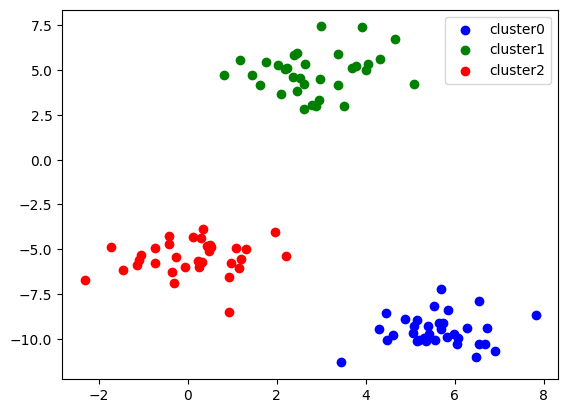

In [ ]:
#クラスターごとにデータを分割
cluster0 = data[data["cluster"]==0]
cluster1 = data[data["cluster"]==1]
cluster2 = data[data["cluster"]==2]

#クラスターごとにデータをプロット
plt.scatter(cluster0["x"], cluster0["y"], color="blue", label="cluster0")
plt.scatter(cluster1["x"], cluster1["y"], color="green", label="cluster1")
plt.scatter(cluster2["x"], cluster2["y"], color="red", label="cluster2")

#凡例を表示
plt.legend()

綺麗に正しく分類できていることがわかります。

## <font color=#0e89b2>2.4 エルボー法</font>

上の例ではクラスター数を3と決め打ちしていましたが、例えばこれがもっとデータが多次元になって、<br>
そもそもクラスター数をいくつに設定すればいいか分からない場合はどうすれば良いでしょうか？<br>
<br>
ここで、<font color=#f27405>エルボー法</font>という技を使います！<br>
エルボー法では、クラスターの重心と、各クラスターに属する各点の距離の和に着目します。<br>
<br>
この図を見てみてください。

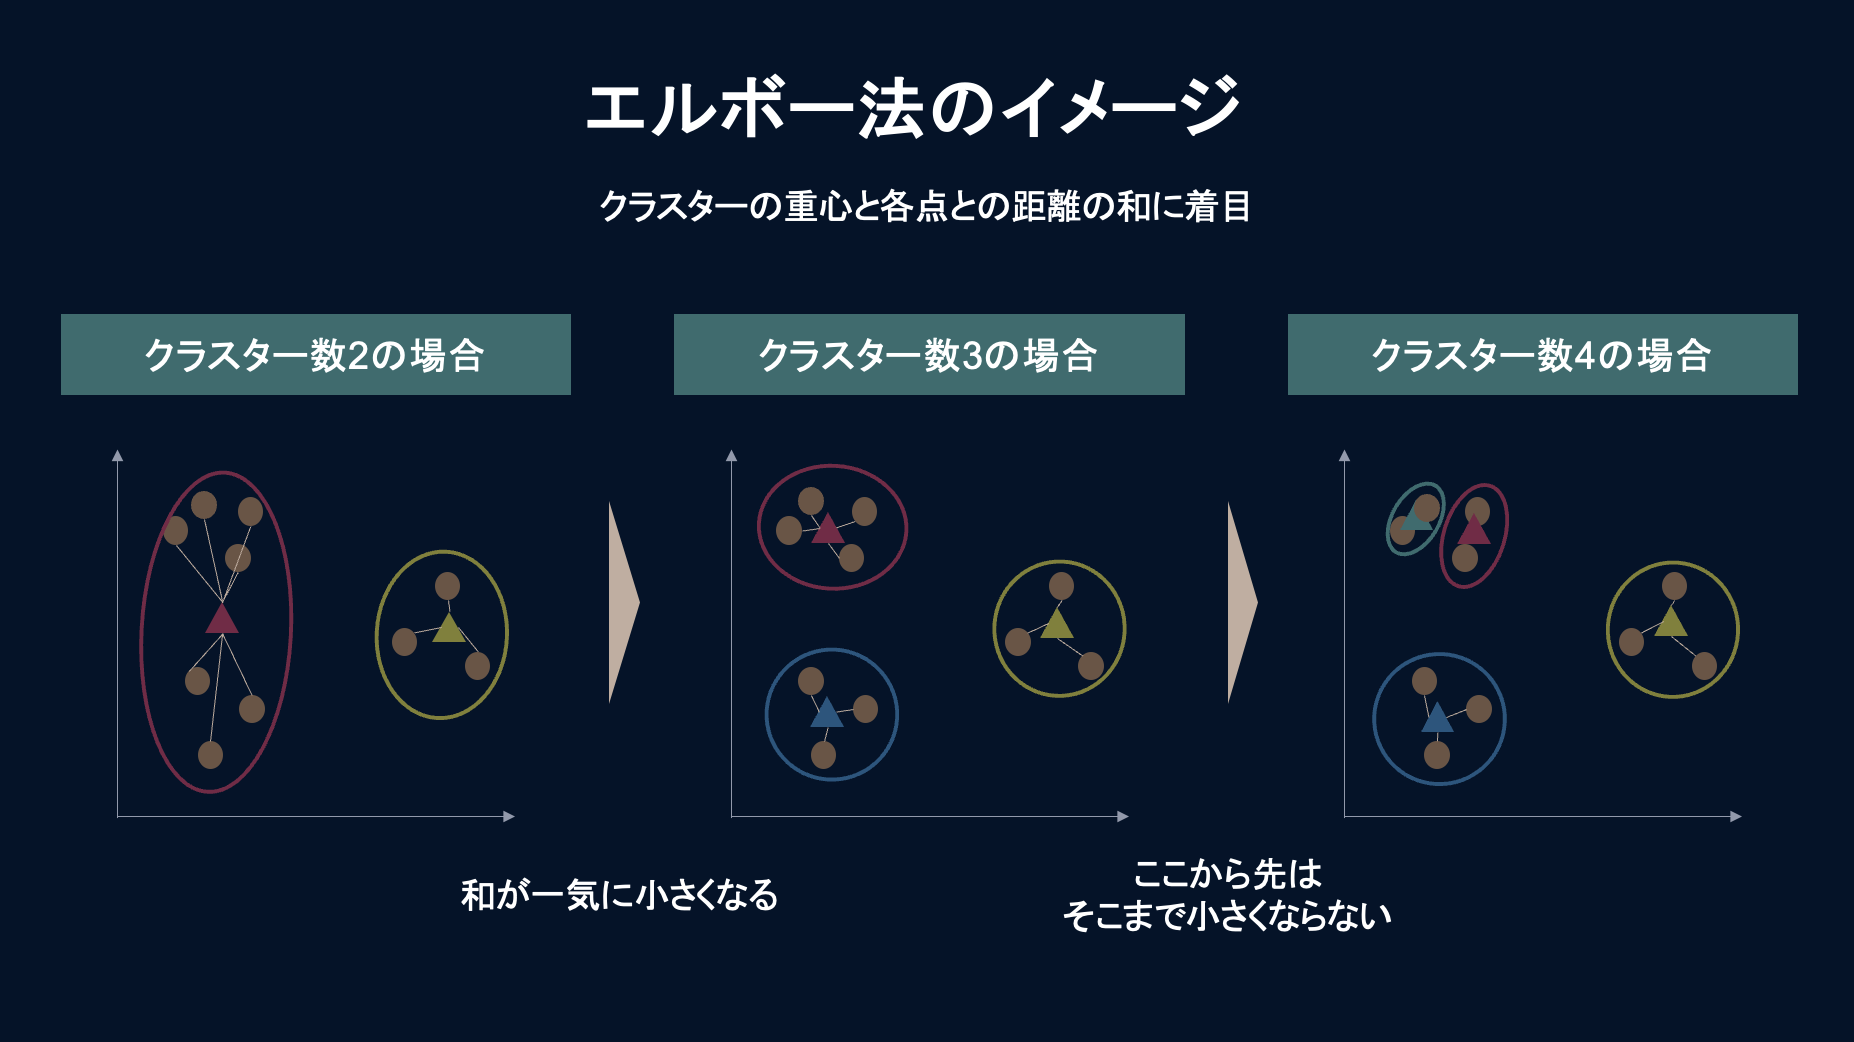

ぱっと見で3つのクラスターに分類されそうな感じで点が配置されています。<br>
これをクラスター数2で分けた場合は、距離の和がある程度大きいのですが、<br>
クラスター数3で分けると一気に距離の和が小さくなることがわかるでしょうか。<br>
<br>
これが正しいクラスター数で分類されている証拠です！<br>
<br>
ではさらに増やしてクラスター数4で分けるとどうなるでしょう。<br>
さらに距離の和は小さくなりますが、クラスター数3のときと比べてそこまで小さくなったわけではありません。<br>
<br>
このように、<font color=#f27405>距離の和はどこかのクラスター数まではガンガン小さくなっていきますが、<br>
どこか以降はそこまで変わらなくなっていく</font>ので、<br>
<font color=#f27405>その変化ポイントを見つけよう、その変化ポイントこそが最適クラスター数である</font><br>
と考えるのがエルボー法です。<br>
<br>
ちなみに、この「距離の和」のことを、<font color=#f27405>クラスター内平方和（WCSS）</font>といいます。
<br>
実際にコードを書いて実装してみましょう。

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

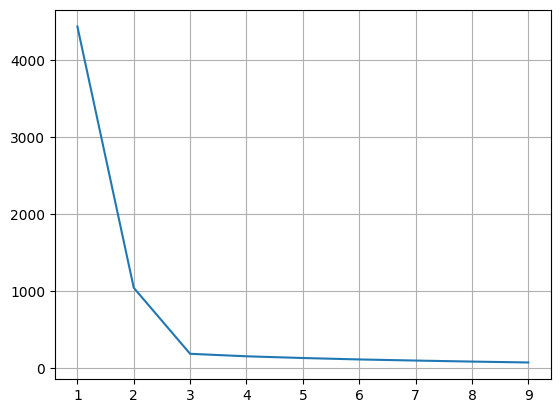

In [ ]:
#####写経#####
#WCSSを求める
ls = []
for i in range(1,10):
  #モデルの作成
  model = KMeans(n_clusters=i)
  #学習
  model.fit(data)
  #距離の和を求めリストに格納
  WCSS = model.inertia_
  ls.append(WCSS)

#グラフに距離の和の変化を描画
plt.plot(range(1,10), ls)
plt.grid(True)

## <font color=#0e89b2>練習問題2：アヤメのクラスタリング</font>

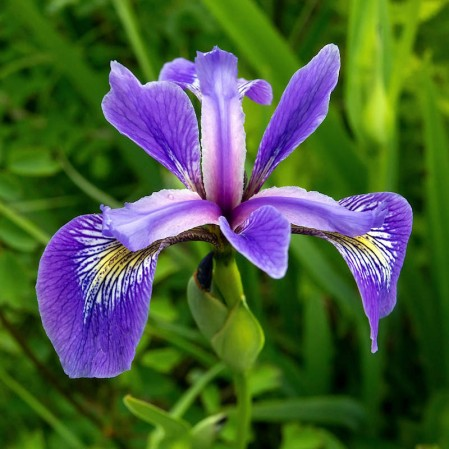

再びアヤメデータを使います。<br>
アヤメのクラスタリングを行ってみましょう。<br>
まずはデータを準備します。

In [ ]:
from sklearn import datasets
iris_data = datasets.load_iris()
iris = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris['species'] = [iris_data.target_names[i] for i in iris_data.target]
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### <font color=#0e89b2>練習問題2-1：モデルの構築</font>

クラスタリングを行ってください。<br>
具体的には、k-Meansでモデルを構築し、各データがどのクラスターに属するか分類した値を出力してください。<br>
なおその際、元データから"species"の値は除いてモデルを構築しましょう。<br>
クラスター数は何でも結構です。

解答

In [ ]:
#モデルの作成
model = KMeans(n_clusters=3)

#学習
model.fit(iris.drop(["species"], axis=1))

#分類した値の出力
model.predict(iris.drop(["species"], axis=1))

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

### <font color=#0e89b2>練習問題2-2：エルボー法</font>

エルボー法を利用して、クラスター数をいくつにするのが最適か、推定してみてください。

解答

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

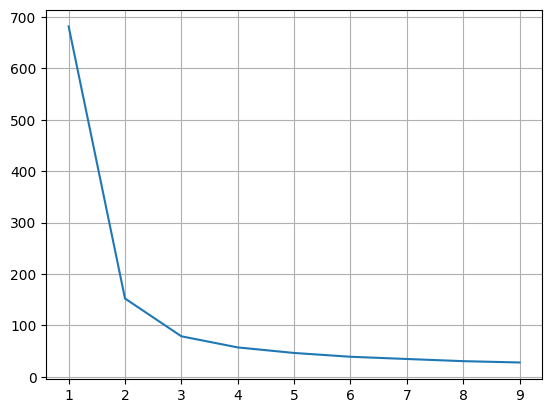

In [ ]:
#WCSSを求める
ls = []
for i in range(1,10):
  #モデルの作成
  model = KMeans(n_clusters=i)
  #学習
  model.fit(iris.drop(["species"], axis=1))
  #距離の和を求めリストに格納
  WCSS = model.inertia_
  ls.append(WCSS)

#グラフに距離の和の変化を描画
plt.plot(range(1,10), ls)
plt.grid(True)

### <font color=#0e89b2>練習問題2-3：ネタバラシ</font>

このデータには、何種類のアヤメの品種が掲載されているでしょうか？<br>
（エルボー法で推定した最適クラスター数とこの品種数が一致していれば嬉しいですね）

解答

In [ ]:
iris["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

# <font color=#0e89b2>3. 総合問題1：サッカー選手のクラスタリング</font>

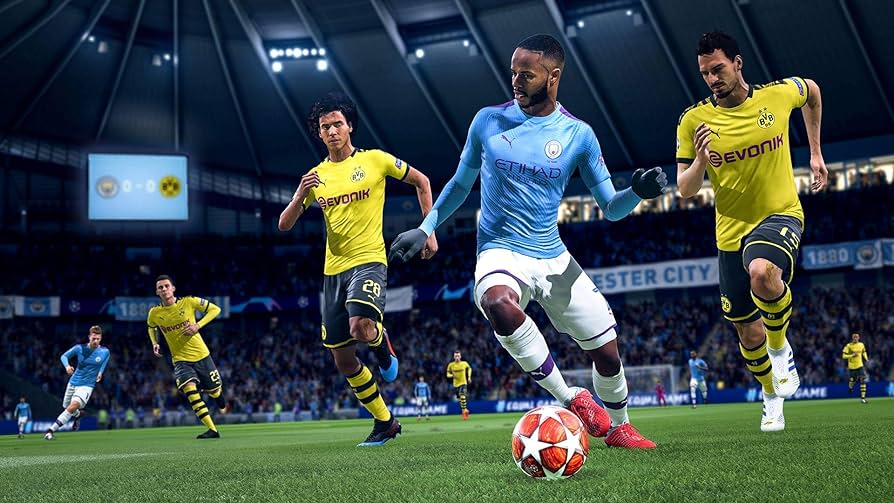

FIFA20というサッカーゲームのデータを使って、サッカー選手のクラスタリングを行ってみましょう。<br>
（サッカーにあまり詳しくない方はスミマセン）<br>
<br>

https://drive.google.com/file/d/1nZwdKevVq3ULjUDXzJMkriQynyesThpk/view?usp=drive_link

主なカラムの意味は下記の通りです。<br>


---
* short_name：選手名
* age：年齢
* height_cm：身長
* weight_kg：体重
* nationality：国籍
* club：所属クラブチーム
* overall：総合能力値
* value_eur：市場価値（ユーロ）
* team_position：ポジション
* pace：スピード
* shooting：シュート能力
* passing：パス能力
* dribbling：ドリブル能力
* defending：ディフェンス能力
* physic；フィジカル


---



◆予備知識：ポジションについて<br>
サッカーのポジションは大きく、フォワード（攻撃）、ミッドフィルダー（中盤）、ディフェンス（守備）、ゴールキーパーの4つに分かれます。<br>
FIFAではさらに下記のように、細かくポジションを分けて定義されています。<br>


---
* フォワード
 * ST：センターフォワード。ゴール前で積極的にゴールを狙う。
 * LW・RW:ウィング。サイドの高い位置から攻撃参加し、チャンスを演出したり自らゴールも狙う。
 * CF：セカンドトップ。STより低めの位置でプレーし、自らゴールを狙うだけでなく、周りを使ったプレーもする。（FIFAの定義では、STがセンターフォワードで、CFがセカンドトップと、なぜか逆になっていることに注意)
* ミッドフィルダー
 * AM：アタッキングミッドフィルダー。攻撃的な中盤の選手。
 * LM・CM・RM：中盤のゲームコントロール役。Lは左、Cは中央、Rは右寄りのポジション。
 * DM：ディフェンシブミッドフィルダー。中盤の低い位置で守備を担う選手。
 * WB…ウィングバック。SBよりもやや高い位置を取り、攻撃・守備を行う。
* ディフェンス
 * CB:センターバック。自陣ゴール前中央で守備を行う、守備の要。
 * SB：サイドバック。サイドの守備役。攻撃にも積極的に参加する。
 * SW：スイーパー。CBのさらに後ろに位置する。
* ゴールキーパー

---



In [ ]:
#相対パスでファイルを読み込む
fifa = pd.read_csv("sample_data/fifa20.csv", encoding ="utf-8")
fifa = fifa[["short_name", "age", "height_cm", "weight_kg", "nationality", "club", "overall", "value_eur", "team_position", "pace", "shooting", "passing", "dribbling", "defending", "physic",
             "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy", "attacking_short_passing", "attacking_volleys", "skill_dribbling", "skill_curve", "skill_fk_accuracy",
             "skill_long_passing", "skill_ball_control", "movement_acceleration", "movement_sprint_speed", "movement_agility", "movement_reactions", "movement_balance",
             "power_shot_power", "power_jumping", "power_stamina", "power_strength", "power_long_shots", "mentality_aggression", "mentality_interceptions", "mentality_positioning",
             "mentality_vision", "mentality_penalties", "mentality_composure", "defending_marking", "defending_standing_tackle", "defending_sliding_tackle"]]

fifa.head()

,short_name,age,height_cm,weight_kg,nationality,club,overall,value_eur,team_position,pace,...,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle
0,L. Messi,32,170,72,Argentina,FC Barcelona,94,95500000,RW,87.0,...,94,48,40,94,94,75,96,33,37,26
1,Cristiano Ronaldo,34,187,83,Portugal,Juventus,93,58500000,LW,90.0,...,93,63,29,95,82,85,95,28,32,24
2,Neymar Jr,27,175,68,Brazil,Paris Saint-Germain,92,105500000,CAM,91.0,...,84,51,36,87,90,90,94,27,26,29
3,J. Oblak,26,188,87,Slovenia,Atlético Madrid,91,77500000,GK,NaN,...,12,34,19,11,65,11,68,27,12,18
4,E. Hazard,28,175,74,Belgium,Real Madrid,91,90000000,LW,91.0,...,80,54,41,87,89,88,91,34,27,22


## <font color=#0e89b2>3.1 総合問題1-1：データ分析</font>

(1) 日本人で総合能力値の高い選手トップ3を特定してください。

解答

In [ ]:
fifa[fifa["nationality"] == 'Japan'].sort_values("overall", ascending=False)[["short_name"]].head(3)

,short_name
520,M. Hasebe
614,S. Nakajima
702,S. Kagawa


(2) 強豪クラブチームトップ10を特定してください。<br>
ただし「強豪」とは、総合能力値が高い所属選手トップ10人を抜粋した時に、その総合能力値の和が高いことと定義します。


解答

In [ ]:
fifa.groupby("club")['overall'].nlargest(10).groupby("club").sum().sort_values(ascending=False).index[:10]

Index(['FC Barcelona', 'Real Madrid', 'Manchester City', 'Juventus',
       'Liverpool', 'Paris Saint-Germain', 'FC Bayern München',
       'Tottenham Hotspur', 'Napoli', 'Atlético Madrid'],
      dtype='object', name='club')

(3) 一般的にサッカー選手として最も脂が乗るのは、何歳のときだと言えるでしょうか？<br>
以下のように分析してみてください。<br>
* 総合能力値トップ200人をピックアップする
* 下記の年齢区分に従ってヒストグラムを描画し、最も人数の多い年齢区分を特定する
 * 20歳未満
 * 20歳以上23歳以下
 * 24歳以上26歳以下
 * 27歳以上29歳以下
 * 30歳以上33歳以下
 * 34歳以上

解答

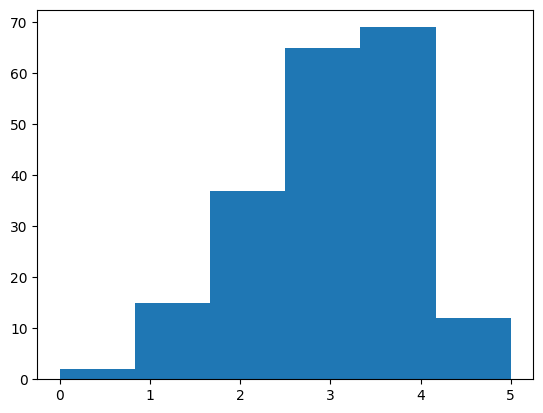

In [ ]:
fifa_top = fifa.sort_values("overall", ascending=False).head(200)
bins = [0, 19, 23, 26, 29, 33, 100]
fifa_top['age_category'] = pd.cut(fifa_top['age'], bins=bins, labels=range(6))
plt.hist(fifa_top['age_category'], bins=6)
plt.show()

## <font color=#0e89b2>3.2 総合問題1-2：選手のクラスタリング</font>

サッカー選手全体を対象としてクラスタリングすると、ポジションによってクラスターが分かれることが予想できます。<br>
（例えば攻撃力が高い選手はフォワード、守備力が高い選手はディフェンス、のように）<br>
<br>
では、フォワードの選手の中でも、選手のタイプによっていくつかのクラスターに分かれるでしょうか？<br>
例えば筋骨隆々のパワータイプ、小柄なテクニシャンタイプ、などと分かれるかもしれません。

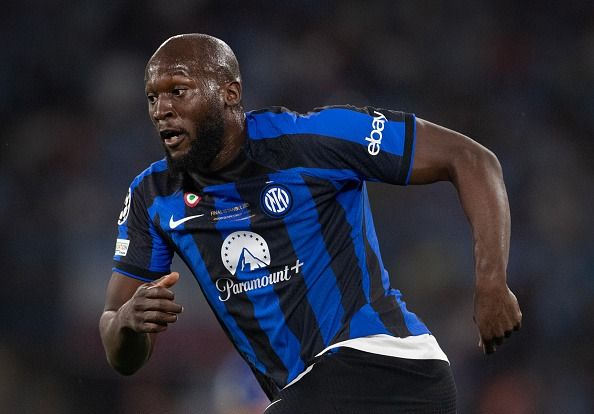

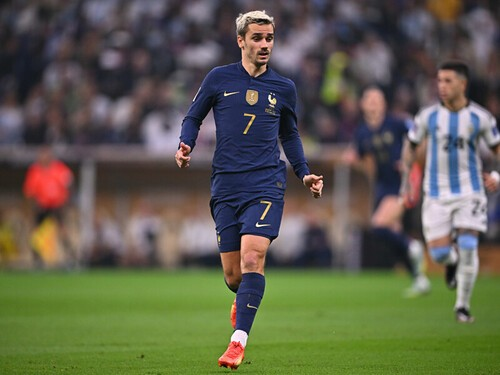

(1) フォワードの選手のみを抜粋したデータフレームを作成してください。<br>
なおフォワードの選手とは、team_positionが以下のいずれかに該当する選手です。<br>
ST/RW/LW/CF

解答

In [ ]:
fifa_forward = fifa[fifa["team_position"].isin(["ST", "RW", "LW", "CF"])]
fifa_forward

,short_name,age,height_cm,weight_kg,nationality,club,overall,value_eur,team_position,pace,...,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle
0,L. Messi,32,170,72,Argentina,FC Barcelona,94,95500000,RW,87.0,...,94,48,40,94,94,75,96,33,37,26
1,Cristiano Ronaldo,34,187,83,Portugal,Juventus,93,58500000,LW,90.0,...,93,63,29,95,82,85,95,28,32,24
4,E. Hazard,28,175,74,Belgium,Real Madrid,91,90000000,LW,91.0,...,80,54,41,87,89,88,91,34,27,22
9,M. Salah,27,175,71,Egypt,Liverpool,90,80500000,RW,93.0,...,84,63,55,92,84,77,91,38,43,41
10,K. Mbappé,20,178,73,France,Paris Saint-Germain,89,93500000,RW,96.0,...,79,62,38,89,80,70,84,34,34,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17333,Cho Jae Wan,23,174,70,Korea Republic,Gangwon FC,55,110000,LW,75.0,...,50,57,14,53,42,59,58,11,11,11
17517,H. McKirdy,22,170,67,Scotland,Carlisle United,54,110000,LW,71.0,...,39,40,32,50,52,45,53,24,32,35
17939,Ye Chugui,24,178,68,China PR,Guangzhou R&F FC,52,70000,RW,52.0,...,47,35,31,52,50,64,50,49,38,35
17993,E. Brown,18,188,84,England,Bolton Wanderers,51,80000,ST,65.0,...,41,32,13,48,44,58,43,11,19,11


(2) フォワードの選手をクラスタリングしてください。<br>
なおその際、エルボー法を使用して、最適なクラスター数を推定した上でクラスタリングを行ってください。<br>
<br>
ヒント：今回は、選手の「タイプ」によってクラスタリングを行いたいので、能力値の絶対値の高低はあまり加味したくありません。<br>
例えば、「スピード95、ドリブル95、フィジカル60」の選手と「スピード70、ドリブル70、フィジカル40」の選手がいた場合、<br>
絶対値的な能力差はありますがタイプとしては似ていそうなので、同じクラスターに分類したいです。<br>
この場合は、どのようなデータ前処理を行えば良いでしょうか？

解答

In [ ]:
ability = ['pace', 'shooting', 'passing', 'dribbling', 'physic']
# タイプを測るために、選手ごとに各能力の和を1にしています
fifa_forward_norm = fifa_forward[ability].div(fifa_forward[ability].sum(axis=1), axis=0)
fifa_forward_norm

,pace,shooting,passing,dribbling,physic
0,0.200924,0.212471,0.212471,0.221709,0.152425
1,0.208333,0.215278,0.189815,0.206019,0.180556
4,0.216667,0.197619,0.204762,0.223810,0.157143
9,0.219858,0.203310,0.191489,0.210402,0.174941
10,0.226950,0.198582,0.184397,0.212766,0.177305
...,...,...,...,...,...
17333,0.263158,0.189474,0.154386,0.189474,0.203509
17517,0.264925,0.190299,0.179104,0.220149,0.145522
17939,0.215768,0.215768,0.165975,0.211618,0.190871
17993,0.257937,0.182540,0.146825,0.214286,0.198413


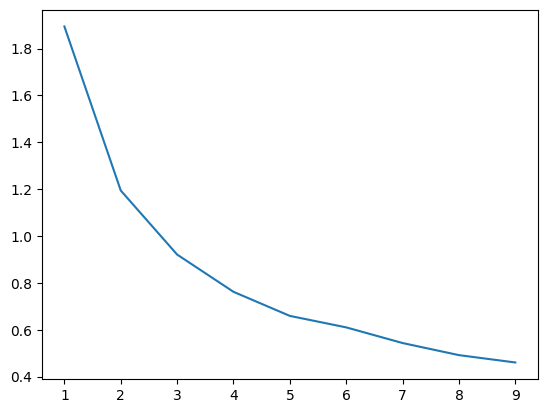

In [ ]:
inertia_values = []
for i in range(1,10):
  model = KMeans(n_clusters=i, n_init='auto')
  model.fit(fifa_forward_norm)
  inertia_values.append(model.inertia_)
plt.plot(range(1,10), inertia_values)
plt.grid(True)
plt.show()

In [ ]:
model = KMeans(n_clusters=4, n_init='auto')
model.fit(fifa_forward_norm)
y_pred = model.predict(fifa_forward_norm)
fifa_forward_norm["y_cluster"] = y_pred
fifa_forward_norm

,pace,shooting,passing,dribbling,physic,y_cluster
0,0.200924,0.212471,0.212471,0.221709,0.152425,1
1,0.208333,0.215278,0.189815,0.206019,0.180556,1
4,0.216667,0.197619,0.204762,0.223810,0.157143,1
9,0.219858,0.203310,0.191489,0.210402,0.174941,1
10,0.226950,0.198582,0.184397,0.212766,0.177305,1
...,...,...,...,...,...,...
17333,0.263158,0.189474,0.154386,0.189474,0.203509,0
17517,0.264925,0.190299,0.179104,0.220149,0.145522,0
17939,0.215768,0.215768,0.165975,0.211618,0.190871,2
17993,0.257937,0.182540,0.146825,0.214286,0.198413,0


(3) (2)のクラスタリング結果に対して、各クラスターがどのような特徴で分けられているか、考察してみてください。

解答

y_cluster0：スピードが速いタイプ。  
y_cluster1：パスが上手いタイプ（おそらく点を決めるよりもアシストが得意なタイプでしょう）。  
y_cluster2：全体的にバランスが良いタイプ。  
y_cluster3：フィジカルが強いタイプ。  

## <font color=#0e89b2>3.3 総合問題1-3：選手の市場価値の予測</font>

(1) 選手の市場価値（value_eur）を推定する回帰モデルを構築し、スコア（決定係数）を算出してください。<br>
なるべくスコアの高いモデルを構築してみましょう。

解答

In [ ]:
from sklearn.linear_model import LinearRegression
columns = ['age', 'height_cm', 'weight_kg', 'overall', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
fifa.fillna(fifa.median(), inplace=True)
X = fifa[columns]
y = fifa["value_eur"]
model = LinearRegression()
model.fit(X, y)
model.score(X, y)

<ipython-input-131-f2f406dcbf2c>:3: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  fifa.fillna(fifa.median(), inplace=True)


0.4697829141726265

(2) 選手の市場価値には、総合能力値以外の要素がどのように影響していそうでしょうか？<br>
分析してみてください。

解答

例)パス、ドリブルと市場価値の相関係数が高いため、これらの要素が深く関係していると考えられる。